In [23]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import NEOfaster as nf
import NEOMOD3 as nm3
import neoom as no
import S3Marray as sm
import S3M_fullversion as smfull
import neoonlyS3M as neo3m
import trojans as tjn
import tnos as tn
import importlib
from functools import reduce
importlib.reload(nm3)

<module 'NEOMOD3' from '/astro/users/ds2004/digest3/NEOMOD3.py'>

In [25]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()


In [26]:
df.columns

Index(['iH', 'ia', 'ie', 'ii', 'binned mod.', 'nu6', '3:1', '5:2', '7:3',
       '8:3', '9:4', '11:5', '2:1', 'inner', 'Hun', 'Pho', 'JFC', 'a_AU', 'e'],
      dtype='object')

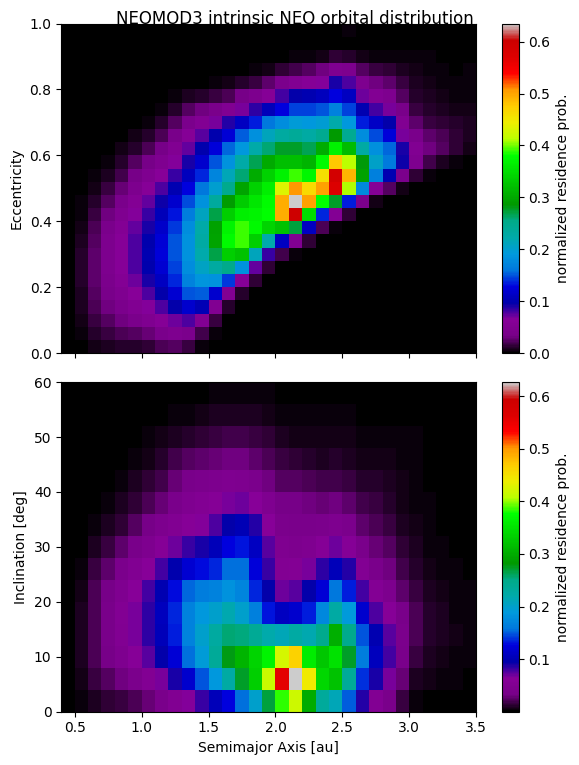

In [27]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel = (H_center >= 15.0) & (H_center <= 28.0)
a_sel = (a_center >= 0.4)  & (a_center <= 3.5)
e_sel = (e_center >= 0.0)  & (e_center < 1.0)
i_sel = (i_center >= 0.0)  & (i_center <= 60.0)

# sets the 4d array to specific ranges
sub = array4D[h_sel, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub = sub[:, a_sel, :, :]        # cut on a
ae_sub = ae_sub[:, :, e_sel, :]     # cut on e
ae_sub = ae_sub[:, :, :, i_sel]     # cut on i
ae_grid = ae_sub.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid = ae_grid / ae_grid.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub = sub[:, a_sel, :, :]        
ai_sub = ai_sub[:, :, :, i_sel]     
ai_grid = ai_sub.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid = ai_grid / ai_grid.max()

# to make it more smooth

ae_grid_plot = gaussian_filter(ae_grid, sigma=0.7)
ai_grid_plot = gaussian_filter(ai_grid, sigma=0.7)


da = a_center[1] - a_center[0]
de = e_center[1] - e_center[0]
di = i_center[1] - i_center[0]

a_c = a_center[a_sel]
e_c = e_center[e_sel]
i_c = i_center[i_sel]

a_edges = np.concatenate(([a_c[0] - da/2], a_c + da/2))
e_edges = np.concatenate(([e_c[0] - de/2], e_c + de/2))
i_edges = np.concatenate(([i_c[0] - di/2], i_c + di/2))



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1 = ax1.pcolormesh(a_edges, e_edges, ae_grid_plot.T,
                     shading='auto', cmap='nipy_spectral')
ax1.set_ylabel("Eccentricity")
ax1.set_ylim(0.0, 1.0)
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label("normalized residence prob.")


# Panel (b): a–i
im2 = ax2.pcolormesh(a_edges, i_edges, ai_grid_plot.T,
                     shading='auto', cmap='nipy_spectral')
ax2.set_xlabel("Semimajor Axis [au]")
ax2.set_ylabel("Inclination [deg]")
ax2.set_ylim(0.0, 60.0)
cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label("normalized residence prob.")



fig.suptitle("NEOMOD3 intrinsic NEO orbital distribution", y=0.95)
fig.tight_layout()


In [14]:
s3m = sm.define_s3m()
s3m,array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = sm.s3m_array(s3m)

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


In [15]:
s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,S1000000a,COM,3.01822,0.05208,22.56035,211.00286,335.42134,51575.94061,14.20,54800.0,1,6,-1,Python,3.184045
1,S1000001a,COM,2.10974,0.07518,4.91571,209.40298,322.66447,54205.77161,20.57,54800.0,1,6,-1,Python,2.281244
2,S1000002a,COM,2.80523,0.07777,1.24945,112.52284,139.86858,54468.71747,14.65,54800.0,1,6,-1,Python,3.041790
3,S1000003a,COM,2.10917,0.13219,1.46615,266.54621,232.24412,54212.16304,19.58,54800.0,1,6,-1,Python,2.430451
4,S1000004a,COM,2.17676,0.19949,12.92422,162.14580,192.22312,51895.46586,10.56,54800.0,1,6,-1,Python,2.719216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13883356,S10d5plza,COM,1.29977,0.58220,20.58311,180.18060,248.72915,54117.83912,26.54,54800.0,1,6,-1,Python,3.110986
13883357,S10d5vtGa,COM,1.31752,0.28101,11.62774,160.50980,98.45125,53387.64646,26.28,54800.0,1,6,-1,Python,1.832459
13883358,S10d5zr1a,COM,1.31100,0.41152,21.99857,249.34945,265.76277,52433.74417,26.41,54800.0,1,6,-1,Python,2.227773
13883359,S10d5zPua,COM,1.31109,0.52347,28.61382,322.50347,190.09049,51540.29687,26.44,54800.0,1,6,-1,Python,2.751327


In [16]:
s3m.to_csv('s3m_data.csv', index=False)

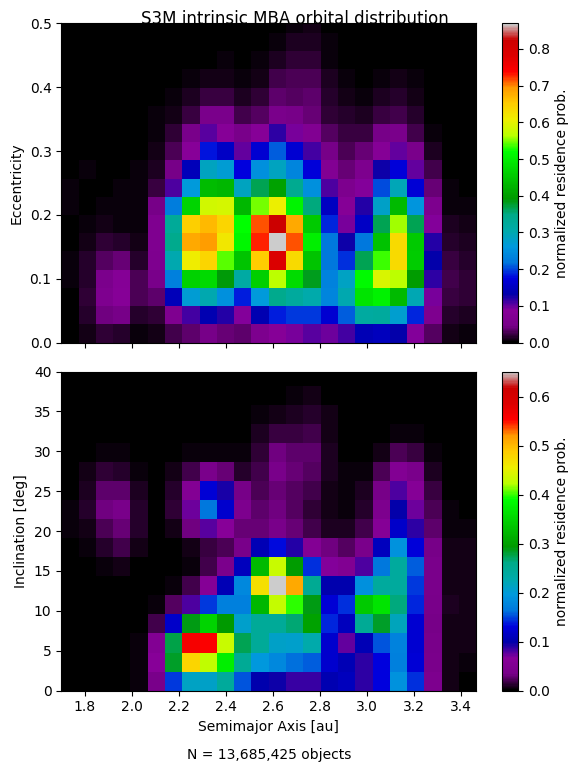

In [41]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel1 = (H_center_s3m >= 15.0) & (H_center_s3m <= 28.0)
a_sel1 = (a_center_s3m >= 0.4)  & (a_center_s3m <= 3.5)
e_sel1 = (e_center_s3m >= 0.0)  & (e_center_s3m < 1.0)
i_sel1 = (i_center_s3m >= 0.0)  & (i_center_s3m <= 60.0)

# sets the 4d array to specific ranges
sub1 = array4D_s3m[h_sel1, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub1 = sub1[:, a_sel1, :, :]        # cut on a
ae_sub1 = ae_sub1[:, :, e_sel1, :]     # cut on e
ae_sub1 = ae_sub1[:, :, :, i_sel1]     # cut on i
ae_grid1 = ae_sub1.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid1 = ae_grid1 / ae_grid1.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub1 = sub1[:, a_sel1, :, :]        
ai_sub1 = ai_sub1[:, :, :, i_sel1]     
ai_grid1 = ai_sub1.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid1 = ai_grid1 / ai_grid1.max()

# to make it more smooth

ae_grid_plot1 = gaussian_filter(ae_grid1, sigma=0.7)
ai_grid_plot1 = gaussian_filter(ai_grid1, sigma=0.7)


da1 = a_center_s3m[1] - a_center_s3m[0]
de1 = e_center_s3m[1] - e_center_s3m[0]
di1 = i_center_s3m[1] - i_center_s3m[0]

a_c1 = a_center_s3m[a_sel1]
e_c1 = e_center_s3m[e_sel1]
i_c1 = i_center_s3m[i_sel1]

a_edges1 = np.concatenate(([a_c1[0] - da1/2], a_c1 + da1/2))
e_edges1 = np.concatenate(([e_c1[0] - de1/2], e_c1 + de1/2))
i_edges1 = np.concatenate(([i_c1[0] - di1/2], i_c1 + di1/2))

# how many S3M objects fall in the plotted H, a, e, i ranges?
count_objects1 = s3m[
    (s3m["H"] >= 15.0) & (s3m["H"] <= 28.0) &   
    (s3m["a"] >= 0.4)  & (s3m["a"] <= 3.5)  &   
    (s3m["e"] >= 0.0)  & (s3m["e"] <  1.0)  &   
    (s3m["i"] >= 0.0)  & (s3m["i"] <= 60.0)     
].shape[0]


fig1, (ax1_s3m, ax2_s3m) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1_s3m = ax1_s3m.pcolormesh(a_edges1, e_edges1, ae_grid_plot1.T,
                     shading='auto', cmap='nipy_spectral')
ax1_s3m.set_ylabel("Eccentricity")
ax1_s3m.set_ylim(0.0, 0.5)
cbar1 = fig1.colorbar(im1_s3m, ax=ax1_s3m)
cbar1.set_label("normalized residence prob.")

# Panel (b): a–i
im2_s3m = ax2_s3m.pcolormesh(a_edges1, i_edges1, ai_grid_plot1.T,
                     shading='auto', cmap='nipy_spectral')
ax2_s3m.set_xlabel("Semimajor Axis [au]")
ax2_s3m.set_ylabel("Inclination [deg]")
ax2_s3m.set_ylim(0.0, 40.0)
cbar2 = fig1.colorbar(im2_s3m, ax=ax2_s3m)
cbar2.set_label("normalized residence prob.")

ax2_s3m.text(0.5, -0.18,
         f"N = {count_objects1:,} objects",
         transform=ax2_s3m.transAxes,
         ha="center", va="top", fontsize=10)


fig1.suptitle("S3M intrinsic MBA orbital distribution", y=0.95)
fig1.tight_layout()


In [17]:
s3m_full = smfull.define_s3m()

['S0.s3m', 'S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m', 'SH.s3m', 'SI.s3m', 'SJ.s3m', 'SL.s3m', 'SR.s3m', 'SS.s3m', 'ST.s3m', 'St5.s3m']
The final df is done.


In [18]:
s3m_full

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,S0000001a,COM,1.251459,0.382244,9.304721,252.063850,185.610748,54067.969964,10.315,54466.0,1,6,-1,MOPS,2.025814
1,S0000002a,COM,1.286219,0.662518,18.303865,132.486568,80.463153,54670.088589,10.818,54466.0,1,6,-1,MOPS,3.811219
2,S0000003a,COM,0.617193,0.645272,10.302493,67.484378,182.131418,54522.349738,11.175,54466.0,1,6,-1,MOPS,1.739907
3,S0000004a,COM,0.383306,0.856419,16.988463,117.793282,242.430598,54973.510299,11.452,54466.0,1,6,-1,MOPS,2.669612
4,S0000005a,COM,0.569264,0.772125,22.761089,314.323204,73.119299,54075.567352,11.678,54466.0,1,6,-1,MOPS,2.498139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14608600,St500KNfa,COM,5.056320,0.045220,15.566800,187.283000,151.605810,47151.013490,18.000,54800.0,1,6,-1,Python,5.295796
14608601,St500KNga,COM,4.782110,0.093630,13.513000,57.662000,275.327700,46937.239020,18.000,54800.0,1,6,-1,Python,5.276112
14608602,St500KNha,COM,4.773200,0.077770,10.543800,329.641000,149.433230,47733.392870,18.000,54800.0,1,6,-1,Python,5.175715
14608603,St500KNia,COM,4.997150,0.049460,34.880100,120.443000,284.497300,46679.404060,18.000,54800.0,1,6,-1,Python,5.257170


In [19]:
s3m,array4D_s3mfull, H_center_s3mfull, a_center_s3mfull, e_center_s3mfull, i_center_s3mfull = sm.s3m_array(s3m)

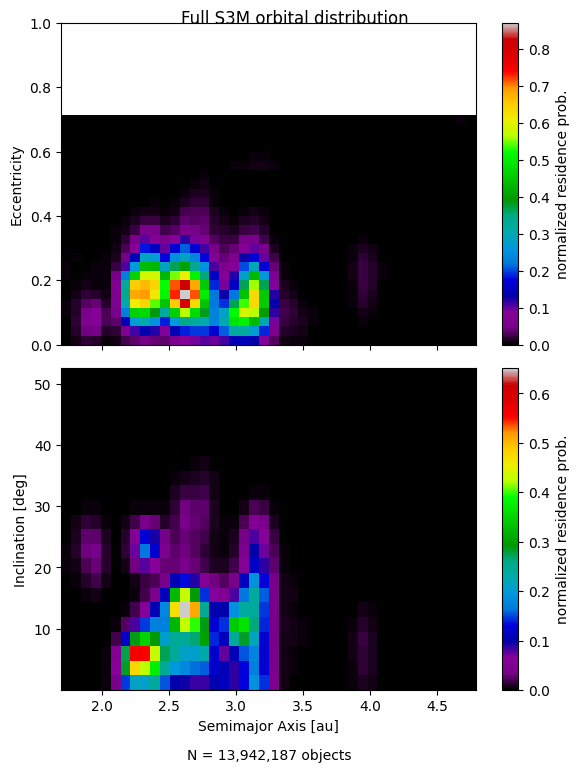

In [47]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel2 = (H_center_s3mfull >= 15.0) & (H_center_s3mfull <= 28.0)
a_sel2 = (a_center_s3mfull >= 0.0)  & (a_center_s3mfull <= 7.5)
e_sel2 = (e_center_s3mfull >= 0.0)  & (e_center_s3mfull < 1.0)
i_sel2 = (i_center_s3mfull >= 0.0)  & (i_center_s3mfull <= 60.0)

# sets the 4d array to specific ranges
sub2 = array4D_s3mfull[h_sel2, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub2 = sub2[:, a_sel2, :, :]        # cut on a
ae_sub2 = ae_sub2[:, :, e_sel2, :]     # cut on e
ae_sub2 = ae_sub2[:, :, :, i_sel2]     # cut on i
ae_grid2 = ae_sub2.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid2 = ae_grid2 / ae_grid2.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub2 = sub2[:, a_sel2, :, :]        
ai_sub2 = ai_sub2[:, :, :, i_sel2]     
ai_grid2 = ai_sub2.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid2 = ai_grid2 / ai_grid2.max()

# to make it more smooth

ae_grid_plot2 = gaussian_filter(ae_grid2, sigma=0.7)
ai_grid_plot2 = gaussian_filter(ai_grid2, sigma=0.7)


da2 = a_center_s3m[1] - a_center_s3m[0]
de2 = e_center_s3m[1] - e_center_s3m[0]
di2 = i_center_s3m[1] - i_center_s3m[0]

a_c2 = a_center_s3mfull[a_sel2]
e_c2 = e_center_s3mfull[e_sel2]
i_c2 = i_center_s3mfull[i_sel2]

a_edges2 = np.concatenate(([a_c2[0] - da2/2], a_c2 + da2/2))
e_edges2 = np.concatenate(([e_c2[0] - de2/2], e_c2 + de2/2))
i_edges2 = np.concatenate(([i_c2[0] - di2/2], i_c2 + di2/2))


count_objects2 = s3m_full[
    (s3m_full["H"] >= 15.0) & (s3m_full["H"] <= 28.0) &   
    (s3m_full["a"] >= 0.4)  & (s3m_full["a"] <= 3.5)  &   
    (s3m_full["e"] >= 0.0)  & (s3m_full["e"] <  1.0)  &   
    (s3m_full["i"] >= 0.0)  & (s3m_full["i"] <= 60.0)     
].shape[0]

fig2, (ax1_s3mfull, ax2_s3mfull) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1_s3mfull = ax1_s3mfull.pcolormesh(a_edges2, e_edges2, ae_grid_plot2.T,
                     shading='auto', cmap='nipy_spectral')
ax1_s3mfull.set_ylabel("Eccentricity")
ax1_s3mfull.set_ylim(0.0, 1.0)
cbar1 = fig2.colorbar(im1_s3mfull, ax=ax1_s3mfull)
cbar1.set_label("normalized residence prob.")

# Panel (b): a–i
im2_s3mfull = ax2_s3mfull.pcolormesh(a_edges2, i_edges2, ai_grid_plot2.T,
                     shading='auto', cmap='nipy_spectral')
ax2_s3mfull.set_xlabel("Semimajor Axis [au]")
ax2_s3mfull.set_ylabel("Inclination [deg]")
ax2_s3m.set_ylim(0.0, 60.0)
cbar2 = fig2.colorbar(im2_s3mfull, ax=ax2_s3mfull)
cbar2.set_label("normalized residence prob.")

ax2_s3mfull.text(0.5, -0.18,
         f"N = {count_objects2:,} objects",
         transform=ax2_s3mfull.transAxes,
         ha="center", va="top", fontsize=10)

fig2.suptitle("Full S3M orbital distribution", y=0.95)
fig2.tight_layout()


In [21]:
# now with only neo from s3m

In [28]:
neo_s3m = neo3m.define_s3m()

['S0.s3m']
The final df is done.


In [29]:
neo_s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,S0000001a,COM,1.251459,0.382244,9.304721,252.063850,185.610748,54067.969964,10.315,54466.0,1,6,-1,MOPS,2.025814
1,S0000002a,COM,1.286219,0.662518,18.303865,132.486568,80.463153,54670.088589,10.818,54466.0,1,6,-1,MOPS,3.811219
2,S0000003a,COM,0.617193,0.645272,10.302493,67.484378,182.131418,54522.349738,11.175,54466.0,1,6,-1,MOPS,1.739907
3,S0000004a,COM,0.383306,0.856419,16.988463,117.793282,242.430598,54973.510299,11.452,54466.0,1,6,-1,MOPS,2.669612
4,S0000005a,COM,0.569264,0.772125,22.761089,314.323204,73.119299,54075.567352,11.678,54466.0,1,6,-1,MOPS,2.498139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268506,S00019Npa,COM,1.120493,0.719870,7.215564,352.065443,22.728064,54356.369662,25.000,54466.0,1,6,-1,MOPS,3.999912
268507,S00019Nqa,COM,0.138585,0.904027,42.936671,97.053777,141.837873,54708.693935,25.000,54466.0,1,6,-1,MOPS,1.443995
268508,S00019Nra,COM,0.183840,0.741100,39.592137,226.887464,45.405407,54453.982901,25.000,54466.0,1,6,-1,MOPS,0.710082
268509,S00019Nsa,COM,1.005092,0.580448,11.451065,194.025698,170.089706,54067.389305,25.000,54466.0,1,6,-1,MOPS,2.395632


In [30]:
neo_s3m,array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = neo3m.s3m_array(neo_s3m)

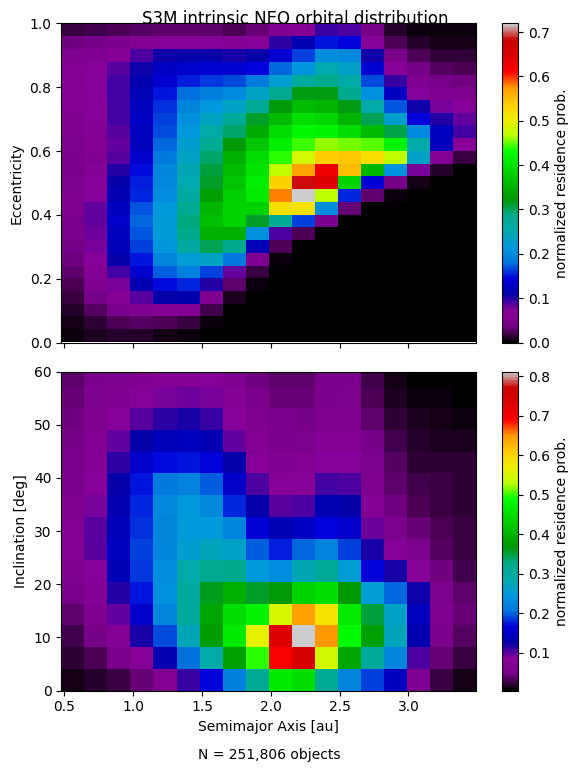

In [31]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel3 = (H_center_neo >= 15.0) & (H_center_neo <= 28.0)
a_sel3 = (a_center_neo >= 0.4)  & (a_center_neo <= 3.5)
e_sel3 = (e_center_neo >= 0.0)  & (e_center_neo < 1.0)
i_sel3 = (i_center_neo >= 0.0)  & (i_center_neo <= 60.0)

# sets the 4d array to specific ranges
sub3 = array4D_neo[h_sel3, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub3 = sub3[:, a_sel3, :, :]        # cut on a
ae_sub3 = ae_sub3[:, :, e_sel3, :]     # cut on e
ae_sub3 = ae_sub3[:, :, :, i_sel3]     # cut on i
ae_grid3 = ae_sub3.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid3 = ae_grid3 / ae_grid3.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub3 = sub3[:, a_sel3, :, :]        
ai_sub3 = ai_sub3[:, :, :, i_sel3]     
ai_grid3 = ai_sub3.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid3 = ai_grid3 / ai_grid3.max()

# to make it more smooth

ae_grid_plot3 = gaussian_filter(ae_grid3, sigma=0.7)
ai_grid_plot3 = gaussian_filter(ai_grid3, sigma=0.7)


da3 = a_center_neo[1] - a_center_neo[0]
de3 = e_center_neo[1] - e_center_neo[0]
di3 = i_center_neo[1] - i_center_neo[0]

a_c3 = a_center_neo[a_sel3]
e_c3 = e_center_neo[e_sel3]
i_c3 = i_center_neo[i_sel3]

a_edges3 = np.concatenate(([a_c3[0] - da3/2], a_c3 + da3/2))
e_edges3 = np.concatenate(([e_c3[0] - de3/2], e_c3 + de3/2))
i_edges3 = np.concatenate(([i_c3[0] - di3/2], i_c3 + di3/2))


count_objects3 = neo_s3m[
    (neo_s3m["H"] >= 15.0) & (neo_s3m["H"] <= 28.0) &   
    (neo_s3m["a"] >= 0.4)  & (neo_s3m["a"] <= 3.5)  &   
    (neo_s3m["e"] >= 0.0)  & (neo_s3m["e"] <  1.0)  &   
    (neo_s3m["i"] >= 0.0)  & (neo_s3m["i"] <= 60.0)     
].shape[0]


fig3, (ax1_neo3m, ax2_neo3m) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1_neo3m = ax1_neo3m.pcolormesh(a_edges3, e_edges3, ae_grid_plot3.T,
                     shading='auto', cmap='nipy_spectral')
ax1_neo3m.set_ylabel("Eccentricity")
ax1_neo3m.set_ylim(0.0, 1.0)

cbar1_neo = fig3.colorbar(im1_neo3m, ax=ax1_neo3m)
cbar1_neo.set_label("normalized residence prob.")

# Panel (b): a–i
im2_neo3m = ax2_neo3m.pcolormesh(a_edges3, i_edges3, ai_grid_plot3.T,
                     shading='auto', cmap='nipy_spectral')
ax2_neo3m.set_xlabel("Semimajor Axis [au]")
ax2_neo3m.set_ylabel("Inclination [deg]")
ax2_neo3m.set_ylim(0.0, 60.0)
cbar2_neo = fig3.colorbar(im2_neo3m, ax=ax2_neo3m)
cbar2_neo.set_label("normalized residence prob.")

ax2_neo3m.text(0.5, -0.18,
         f"N = {count_objects3:,} objects",
         transform=ax2_neo3m.transAxes,
         ha="center", va="top", fontsize=10)

fig3.suptitle("S3M intrinsic NEO orbital distribution", y=0.95)
fig3.tight_layout()


In [32]:
print("H bins selected:", h_sel3.sum())
print("a bins selected:", a_sel3.sum())
print("e bins selected:", e_sel3.sum())
print("i bins selected:", i_sel3.sum())
print("H range:", H_center_neo.min(), "to", H_center_neo.max())
print("a range:", a_center_neo.min(), "to", a_center_neo.max())
print("e range:", e_center_neo.min(), "to", e_center_neo.max())
print("i range:", i_center_neo.min(), "to", i_center_neo.max())


H bins selected: 35
a bins selected: 18
e bins selected: 25
i bins selected: 15
H range: 10.456201923076922 to 24.858798076923076
a range: 0.3937485517815257 to 7.261179652391736
e range: 0.0219319961201 to 0.9795070250369
i range: 2.0440771086535228 to 87.77341232799348


In [28]:
trojans_s3m = tjn.define_s3m()

['St5.s3m']
The final df is done.


In [30]:
tjn_s3m,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = tjn.s3m_array(trojans_s3m)

In [31]:
tjn_s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,St500000a,COM,4.91636,0.05966,7.6084,313.711,150.14863,47268.27529,5.63,54800.0,1,6,-1,Python,5.228279
1,St500001a,COM,4.96652,0.06370,10.4414,100.539,243.70619,54669.39282,6.25,54800.0,1,6,-1,Python,5.304411
2,St500002a,COM,5.01980,0.03319,6.7215,166.404,31.12803,52845.06297,6.36,54800.0,1,6,-1,Python,5.192127
3,St500003a,COM,4.75104,0.09715,18.3859,41.238,206.31396,54666.09533,6.61,54800.0,1,6,-1,Python,5.262269
4,St500004a,COM,4.91459,0.05269,26.1707,188.834,92.77871,46950.71510,6.92,54800.0,1,6,-1,Python,5.187943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179877,St500KNfa,COM,5.05632,0.04522,15.5668,187.283,151.60581,47151.01349,18.00,54800.0,1,6,-1,Python,5.295796
179878,St500KNga,COM,4.78211,0.09363,13.5130,57.662,275.32770,46937.23902,18.00,54800.0,1,6,-1,Python,5.276112
179879,St500KNha,COM,4.77320,0.07777,10.5438,329.641,149.43323,47733.39287,18.00,54800.0,1,6,-1,Python,5.175715
179880,St500KNia,COM,4.99715,0.04946,34.8801,120.443,284.49730,46679.40406,18.00,54800.0,1,6,-1,Python,5.257170


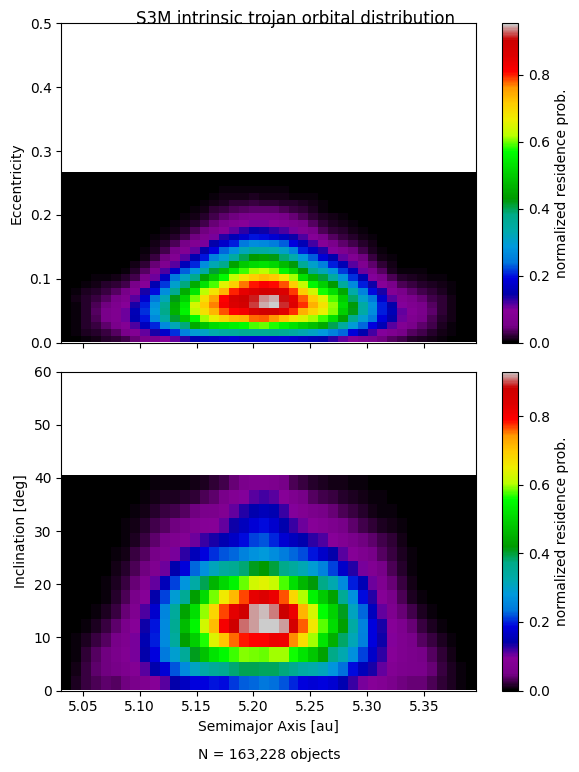

In [50]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel4 = (H_center_tjn >= 15.0) & (H_center_tjn <= 28.0)
a_sel4 = (a_center_tjn >= 3.5)  & (a_center_tjn <= 6.0)
e_sel4 = (e_center_tjn >= 0.0)  & (e_center_tjn < 0.5)
i_sel4 = (i_center_tjn >= 0.0)  & (i_center_tjn <= 40.0)

# sets the 4d array to specific ranges
sub4 = array4D_tjn[h_sel4, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub4 = sub4[:, a_sel4, :, :]        # cut on a
ae_sub4 = ae_sub4[:, :, e_sel4, :]     # cut on e
ae_sub4 = ae_sub4[:, :, :, i_sel4]     # cut on i
ae_grid4 = ae_sub4.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid4 = ae_grid4 / ae_grid4.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub4 = sub4[:, a_sel4, :, :]        
ai_sub4 = ai_sub4[:, :, :, i_sel4]     
ai_grid4 = ai_sub4.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid4 = ai_grid4 / ai_grid4.max()

# to make it more smooth

ae_grid_plot4 = gaussian_filter(ae_grid4, sigma=0.7)
ai_grid_plot4 = gaussian_filter(ai_grid4, sigma=0.7)


da4 = a_center_tjn[1] - a_center_tjn[0]
de4 = e_center_tjn[1] - e_center_tjn[0]
di4 = i_center_tjn[1] - i_center_tjn[0]

a_c4 = a_center_tjn[a_sel4]
e_c4 = e_center_tjn[e_sel4]
i_c4 = i_center_tjn[i_sel4]

a_edges4 = np.concatenate(([a_c4[0] - da4/2], a_c4 + da4/2))
e_edges4 = np.concatenate(([e_c4[0] - de4/2], e_c4 + de4/2))
i_edges4 = np.concatenate(([i_c4[0] - di4/2], i_c4 + di4/2))


count_objects4 = tjn_s3m[
    (tjn_s3m["H"] >= 15.0) & (tjn_s3m["H"] <= 28.0) &   
    (tjn_s3m["a"] >= 3.5)  & (tjn_s3m["a"] <= 6.0)  &   
    (tjn_s3m["e"] >= 0.0)  & (tjn_s3m["e"] <  0.5)  &   
    (tjn_s3m["i"] >= 0.0)  & (tjn_s3m["i"] <= 60.0)     
].shape[0]

fig4, (ax1_tjn, ax2_tjn) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1_tjn = ax1_tjn.pcolormesh(a_edges4, e_edges4, ae_grid_plot4.T,
                     shading='auto', cmap='nipy_spectral')
ax1_tjn.set_ylabel("Eccentricity")
ax1_tjn.set_ylim(0.0, 0.5)

cbar1_tjn = fig4.colorbar(im1_tjn, ax=ax1_tjn)
cbar1_tjn.set_label("normalized residence prob.")

# Panel (b): a–i
im2_tjn = ax2_tjn.pcolormesh(a_edges4, i_edges4, ai_grid_plot4.T,
                     shading='auto', cmap='nipy_spectral')
ax2_tjn.set_xlabel("Semimajor Axis [au]")
ax2_tjn.set_ylabel("Inclination [deg]")
ax2_tjn.set_ylim(0.0, 60.0)
cbar2_tjn = fig4.colorbar(im2_tjn, ax=ax2_tjn)
cbar2_tjn.set_label("normalized residence prob.")

ax2_tjn.text(0.5, -0.18,
         f"N = {count_objects4:,} objects",
         transform=ax2_tjn.transAxes,
         ha="center", va="top", fontsize=10)

fig4.suptitle("S3M intrinsic trojan orbital distribution", y=0.95)
fig4.tight_layout()


In [53]:
# for tnos from s3m

In [54]:
tnos_s3m = tn.define_s3m()

['ST.s3m']
The final df is done.


In [55]:
tnos_s3m,array4D_tn, H_center_tn, a_center_tn, e_center_tn, i_center_tn = tn.s3m_array(tnos_s3m)

In [56]:
tnos_s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,STC00000a,COM,35.19039,0.08370,1.46467,208.12091,337.88990,34856.65638,8.55,54466.0,1,6,-1,SSM,38.404878
1,STC00001a,COM,38.61380,0.03653,8.72457,48.33384,25.63415,44130.75905,8.31,54466.0,1,6,-1,SSM,40.077844
2,STC00002a,COM,37.86288,0.03177,9.59712,8.40560,110.71308,49725.04916,4.72,54466.0,1,6,-1,SSM,39.105254
3,STC00003a,COM,34.78559,0.11761,6.72742,194.89433,230.54255,55263.11279,8.46,54466.0,1,6,-1,SSM,39.422013
4,STC00004a,COM,33.72462,0.11079,5.31140,269.70531,250.46489,93548.88039,7.26,54466.0,1,6,-1,SSM,37.926497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48677,STR001yZa,COM,30.70597,0.15935,10.32317,213.39149,270.32600,86051.93117,7.94,54466.0,1,6,-1,SSM,36.526462
48678,STR001z0a,COM,33.01305,0.09654,8.98718,144.25849,7.89000,90480.35745,7.99,54466.0,1,6,-1,SSM,36.540688
48679,STR001z1a,COM,29.54459,0.00786,6.44645,6.46782,7.52500,78747.13779,8.55,54466.0,1,6,-1,SSM,29.778650
48680,STR001z2a,COM,34.68616,0.07172,15.38404,44.16722,156.56400,29430.71205,7.12,54466.0,1,6,-1,SSM,37.366053


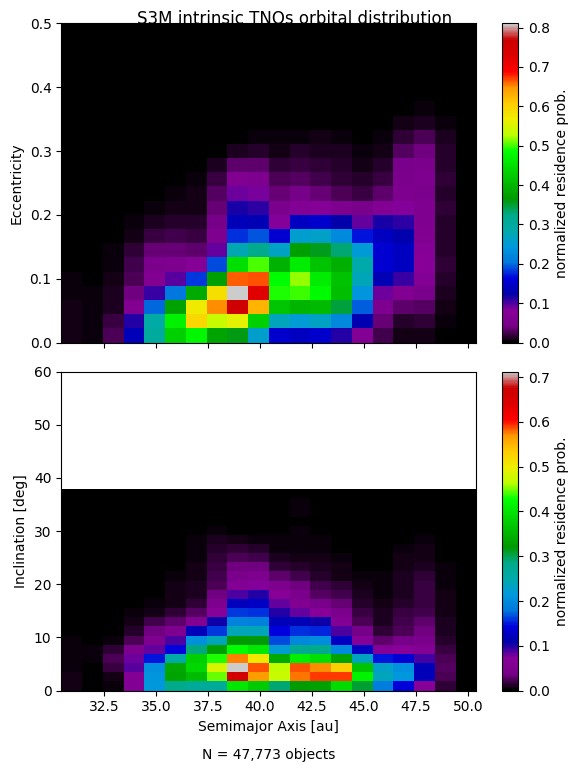

In [65]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel5 = (H_center_tn >= 1.0) & (H_center_tn <= 28.0)
a_sel5 = (a_center_tn >= 30.0)  & (a_center_tn <= 50.0)
e_sel5 = (e_center_tn >= 0.0)  & (e_center_tn < 1.0)
i_sel5 = (i_center_tn >= 0.0)  & (i_center_tn <= 80.0)

# sets the 4d array to specific ranges
sub5 = array4D_tn[h_sel5, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub5 = sub5[:, a_sel5, :, :]        # cut on a
ae_sub5 = ae_sub5[:, :, e_sel5, :]     # cut on e
ae_sub5 = ae_sub5[:, :, :, i_sel5]     # cut on i
ae_grid5 = ae_sub5.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid5 = ae_grid5 / ae_grid5.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub5 = sub5[:, a_sel5, :, :]        
ai_sub5 = ai_sub5[:, :, :, i_sel5]     
ai_grid5 = ai_sub5.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid5 = ai_grid5 / ai_grid5.max()

# to make it more smooth

ae_grid_plot5 = gaussian_filter(ae_grid5, sigma=0.7)
ai_grid_plot5 = gaussian_filter(ai_grid5, sigma=0.7)


da5 = a_center_tn[1] - a_center_tn[0]
de5 = e_center_tn[1] - e_center_tn[0]
di5 = i_center_tn[1] - i_center_tn[0]

a_c5 = a_center_tn[a_sel5]
e_c5 = e_center_tn[e_sel5]
i_c5 = i_center_tn[i_sel5]

a_edges5 = np.concatenate(([a_c5[0] - da5/2], a_c5 + da5/2))
e_edges5 = np.concatenate(([e_c5[0] - de5/2], e_c5 + de5/2))
i_edges5 = np.concatenate(([i_c5[0] - di5/2], i_c5 + di5/2))


count_objects5 = tnos_s3m[
    (tnos_s3m["H"] >= 1.0) & (tnos_s3m["H"] <= 28.0) &   
    (tnos_s3m["a"] >= 30.0)  & (tnos_s3m["a"] <= 50.0)  &   
    (tnos_s3m["e"] >= 0.0)  & (tnos_s3m["e"] <  1.0)  &   
    (tnos_s3m["i"] >= 0.0)  & (tnos_s3m["i"] <= 80.0)     
].shape[0]

fig5, (ax1_tn, ax2_tn) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1_tn = ax1_tn.pcolormesh(a_edges5, e_edges5, ae_grid_plot5.T,
                     shading='auto', cmap='nipy_spectral')
ax1_tn.set_ylabel("Eccentricity")
ax1_tn.set_ylim(0.0, 0.5)

cbar1_tn = fig5.colorbar(im1_tn, ax=ax1_tn)
cbar1_tn.set_label("normalized residence prob.")

# Panel (b): a–i
im2_tn = ax2_tn.pcolormesh(a_edges5, i_edges5, ai_grid_plot5.T,
                     shading='auto', cmap='nipy_spectral')
ax2_tn.set_xlabel("Semimajor Axis [au]")
ax2_tn.set_ylabel("Inclination [deg]")
ax2_tn.set_ylim(0.0, 60.0)
cbar2_tn = fig5.colorbar(im2_tn, ax=ax2_tn)
cbar2_tn.set_label("normalized residence prob.")

ax2_tn.text(0.5, -0.18,
         f"N = {count_objects5:,} objects",
         transform=ax2_tn.transAxes,
         ha="center", va="top", fontsize=10)

fig5.suptitle("S3M intrinsic TNOs orbital distribution", y=0.95)
fig5.tight_layout()


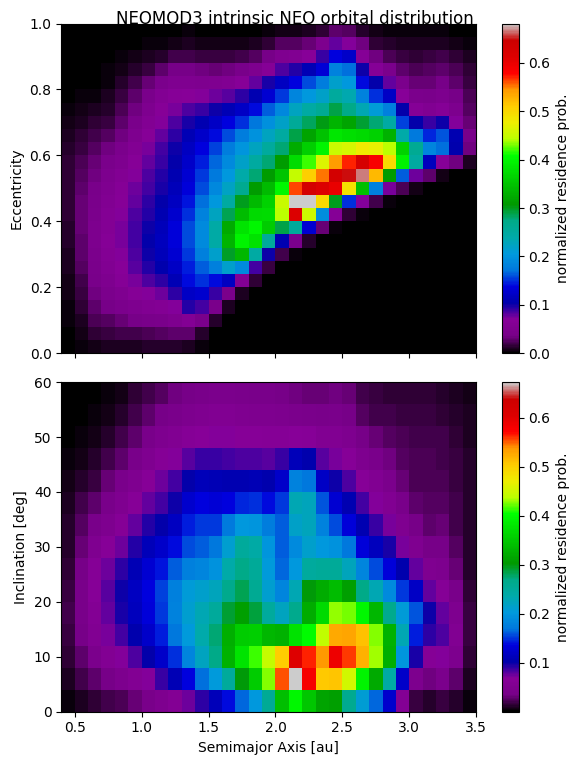

In [33]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel = (H_center >= 15.0) & (H_center <= 20.0)
a_sel = (a_center >= 0.4)  & (a_center <= 3.5)
e_sel = (e_center >= 0.0)  & (e_center < 1.0)
i_sel = (i_center >= 0.0)  & (i_center <= 60.0)

# sets the 4d array to specific ranges
sub = array4D[h_sel, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub = sub[:, a_sel, :, :]        # cut on a
ae_sub = ae_sub[:, :, e_sel, :]     # cut on e
ae_sub = ae_sub[:, :, :, i_sel]     # cut on i
ae_grid = ae_sub.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid = ae_grid / ae_grid.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub = sub[:, a_sel, :, :]        
ai_sub = ai_sub[:, :, :, i_sel]     
ai_grid = ai_sub.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid = ai_grid / ai_grid.max()

# to make it more smooth

ae_grid_plot = gaussian_filter(ae_grid, sigma=0.7)
ai_grid_plot = gaussian_filter(ai_grid, sigma=0.7)


da = a_center[1] - a_center[0]
de = e_center[1] - e_center[0]
di = i_center[1] - i_center[0]

a_c = a_center[a_sel]
e_c = e_center[e_sel]
i_c = i_center[i_sel]

a_edges = np.concatenate(([a_c[0] - da/2], a_c + da/2))
e_edges = np.concatenate(([e_c[0] - de/2], e_c + de/2))
i_edges = np.concatenate(([i_c[0] - di/2], i_c + di/2))



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1 = ax1.pcolormesh(a_edges, e_edges, ae_grid_plot.T,
                     shading='auto', cmap='nipy_spectral')
ax1.set_ylabel("Eccentricity")
ax1.set_ylim(0.0, 1.0)
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label("normalized residence prob.")


# Panel (b): a–i
im2 = ax2.pcolormesh(a_edges, i_edges, ai_grid_plot.T,
                     shading='auto', cmap='nipy_spectral')
ax2.set_xlabel("Semimajor Axis [au]")
ax2.set_ylabel("Inclination [deg]")
ax2.set_ylim(0.0, 60.0)
cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label("normalized residence prob.")



fig.suptitle("NEOMOD3 intrinsic NEO orbital distribution", y=0.95)
fig.tight_layout()


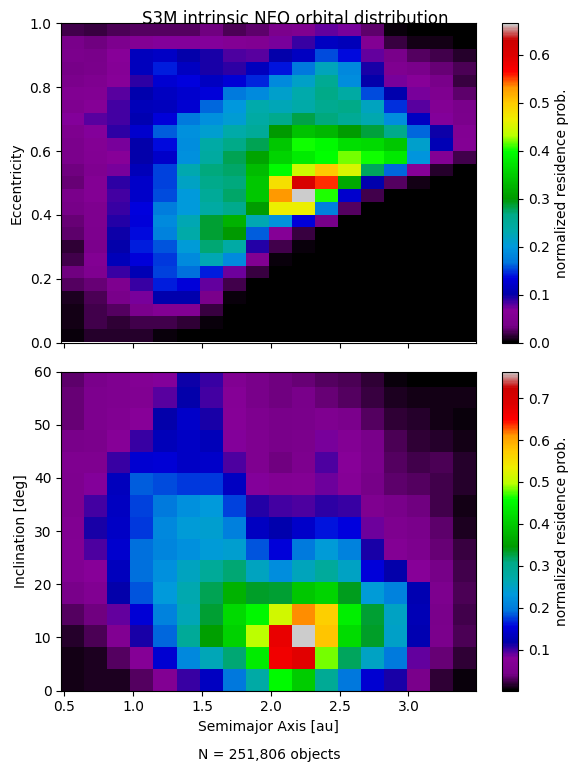

In [34]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel3 = (H_center_neo >= 15.0) & (H_center_neo <= 20.0)
a_sel3 = (a_center_neo >= 0.4)  & (a_center_neo <= 3.5)
e_sel3 = (e_center_neo >= 0.0)  & (e_center_neo < 1.0)
i_sel3 = (i_center_neo >= 0.0)  & (i_center_neo <= 60.0)

# sets the 4d array to specific ranges
sub3 = array4D_neo[h_sel3, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub3 = sub3[:, a_sel3, :, :]        # cut on a
ae_sub3 = ae_sub3[:, :, e_sel3, :]     # cut on e
ae_sub3 = ae_sub3[:, :, :, i_sel3]     # cut on i
ae_grid3 = ae_sub3.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid3 = ae_grid3 / ae_grid3.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub3 = sub3[:, a_sel3, :, :]        
ai_sub3 = ai_sub3[:, :, :, i_sel3]     
ai_grid3 = ai_sub3.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid3 = ai_grid3 / ai_grid3.max()

# to make it more smooth

ae_grid_plot3 = gaussian_filter(ae_grid3, sigma=0.7)
ai_grid_plot3 = gaussian_filter(ai_grid3, sigma=0.7)


da3 = a_center_neo[1] - a_center_neo[0]
de3 = e_center_neo[1] - e_center_neo[0]
di3 = i_center_neo[1] - i_center_neo[0]

a_c3 = a_center_neo[a_sel3]
e_c3 = e_center_neo[e_sel3]
i_c3 = i_center_neo[i_sel3]

a_edges3 = np.concatenate(([a_c3[0] - da3/2], a_c3 + da3/2))
e_edges3 = np.concatenate(([e_c3[0] - de3/2], e_c3 + de3/2))
i_edges3 = np.concatenate(([i_c3[0] - di3/2], i_c3 + di3/2))


count_objects3 = neo_s3m[
    (neo_s3m["H"] >= 15.0) & (neo_s3m["H"] <= 28.0) &   
    (neo_s3m["a"] >= 0.4)  & (neo_s3m["a"] <= 3.5)  &   
    (neo_s3m["e"] >= 0.0)  & (neo_s3m["e"] <  1.0)  &   
    (neo_s3m["i"] >= 0.0)  & (neo_s3m["i"] <= 60.0)     
].shape[0]


fig3, (ax1_neo3m, ax2_neo3m) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1_neo3m = ax1_neo3m.pcolormesh(a_edges3, e_edges3, ae_grid_plot3.T,
                     shading='auto', cmap='nipy_spectral')
ax1_neo3m.set_ylabel("Eccentricity")
ax1_neo3m.set_ylim(0.0, 1.0)

cbar1_neo = fig3.colorbar(im1_neo3m, ax=ax1_neo3m)
cbar1_neo.set_label("normalized residence prob.")

# Panel (b): a–i
im2_neo3m = ax2_neo3m.pcolormesh(a_edges3, i_edges3, ai_grid_plot3.T,
                     shading='auto', cmap='nipy_spectral')
ax2_neo3m.set_xlabel("Semimajor Axis [au]")
ax2_neo3m.set_ylabel("Inclination [deg]")
ax2_neo3m.set_ylim(0.0, 60.0)
cbar2_neo = fig3.colorbar(im2_neo3m, ax=ax2_neo3m)
cbar2_neo.set_label("normalized residence prob.")

ax2_neo3m.text(0.5, -0.18,
         f"N = {count_objects3:,} objects",
         transform=ax2_neo3m.transAxes,
         ha="center", va="top", fontsize=10)

fig3.suptitle("S3M intrinsic NEO orbital distribution", y=0.95)
fig3.tight_layout()


In [61]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np

def interp2d_to_target(src_x, src_y, src_Z, tgt_x, tgt_y):
    """
    src_x, src_y: 1D centers for source grid
    src_Z: shape (len(src_x), len(src_y))  (Z indexed as [x, y])
    tgt_x, tgt_y: 1D centers for target grid
    returns Z on target grid with shape (len(tgt_x), len(tgt_y))
    """
    interp = RegularGridInterpolator(
        (src_x, src_y), src_Z,
        bounds_error=False, fill_value=0.0
    )
    X, Y = np.meshgrid(tgt_x, tgt_y, indexing="ij")
    pts = np.stack([X.ravel(), Y.ravel()], axis=-1)
    return interp(pts).reshape(len(tgt_x), len(tgt_y))

# centers for each model 
a_nm = a_center[(a_center >= 0.4) & (a_center <= 3.5)]
e_nm = e_center[(e_center >= 0.0) & (e_center <  1.0)]
i_nm = i_center[(i_center >= 0.0) & (i_center <= 60.0)]

a_s3 = a_center_neo[(a_center_neo >= 0.4) & (a_center_neo <= 3.5)]
e_s3 = e_center_neo[(e_center_neo >= 0.0) & (e_center_neo <  1.0)]
i_s3 = i_center_neo[(i_center_neo >= 0.0) & (i_center_neo <= 60.0)]

# Regrid S3M onto NEOMOD3 grid
ae_s3m_on_nm = interp2d_to_target(a_s3, e_s3, ae_s3m, a_nm, e_nm)
ai_s3m_on_nm = interp2d_to_target(a_s3, i_s3, ai_s3m, a_nm, i_nm)

# Now difference is:
d_ae = ae_nm - ae_s3m_on_nm
d_ai = ai_nm - ai_s3m_on_nm


In [68]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def centers_to_edges(c):
    dc = c[1] - c[0]
    return np.concatenate(([c[0] - dc/2], c + dc/2))

def edges_to_centers(edges):
    return 0.5 * (edges[:-1] + edges[1:])

def make_ae_ai_grids(array4D, H_center, a_center, e_center, i_center,
                     H_range=(15.0, 20.0), a_range=(0.4, 3.5), e_range=(0.0, 1.0), i_range=(0.0, 60.0),
                     smooth_sigma=0.0, normalize="sum"):
    """
    Returns:
      ae (shape [n_a_sel, n_e_sel]),
      ai (shape [n_a_sel, n_i_sel]),
      a_edges, e_edges, i_edges
    normalize:
      "sum" -> sum to 1 
      "max" -> divide by max
      None  -> no normalization
    """

    h_sel = (H_center >= H_range[0]) & (H_center <= H_range[1])
    a_sel = (a_center >= a_range[0]) & (a_center <= a_range[1])
    e_sel = (e_center >= e_range[0]) & (e_center <  e_range[1])
    i_sel = (i_center >= i_range[0]) & (i_center <= i_range[1])

    sub = array4D[h_sel, :, :, :]  # (nH, na, ne, ni)

    # a-e: sum over H and i  -> (na_sel, ne_sel)
    ae = sub[:, a_sel, :, :][:, :, e_sel, :][:, :, :, i_sel].sum(axis=(0, 3))

    # a-i: sum over H and e  -> (na_sel, ni_sel)
    ai = sub[:, a_sel, :, :][:, :, :, i_sel].sum(axis=(0, 2))

    def norm_grid(g):
        if normalize == "sum":
            s = g.sum()
            return g / s if s > 0 else g
        if normalize == "max":
            m = g.max()
            return g / m if m > 0 else g
        return g

    ae = norm_grid(ae)
    ai = norm_grid(ai)

    if smooth_sigma and smooth_sigma > 0:
        ae = gaussian_filter(ae, sigma=smooth_sigma)
        ai = gaussian_filter(ai, sigma=smooth_sigma)

    a_edges = centers_to_edges(a_center[a_sel])
    e_edges = centers_to_edges(e_center[e_sel])
    i_edges = centers_to_edges(i_center[i_sel])

    return ae, ai, a_edges, e_edges, i_edges


def interp2d_to_target(src_x, src_y, src_Z, tgt_x, tgt_y):
    """
    src_x, src_y: 1D centers for source grid
    src_Z: shape (len(src_x), len(src_y))  (Z indexed as [x, y])
    tgt_x, tgt_y: 1D centers for target grid
    returns Z on target grid with shape (len(tgt_x), len(tgt_y))
    """
    interp = RegularGridInterpolator(
        (src_x, src_y), src_Z,
        bounds_error=False, fill_value=0.0
    )
    X, Y = np.meshgrid(tgt_x, tgt_y, indexing="ij")
    pts = np.stack([X.ravel(), Y.ravel()], axis=-1)
    return interp(pts).reshape(len(tgt_x), len(tgt_y))


# Build grids that are normalized


# NEOMOD3
ae_nm, ai_nm, a_edges_nm, e_edges_nm, i_edges_nm = make_ae_ai_grids(
    array4D, H_center, a_center, e_center, i_center,
    H_range=(15,20), a_range=(0.4,3.5), e_range=(0,1.0), i_range=(0,60),
    smooth_sigma=0.7,
    normalize="sum"
)

# S3M
ae_s3m, ai_s3m, a_edges_s3m, e_edges_s3m, i_edges_s3m = make_ae_ai_grids(
    array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo,
    H_range=(15,20), a_range=(0.4,3.5), e_range=(0,1.0), i_range=(0,60),
    smooth_sigma=0.7,
    normalize="sum"
)


# Use centers derived from the actual edges

a_nm_c = edges_to_centers(a_edges_nm)
e_nm_c = edges_to_centers(e_edges_nm)
i_nm_c = edges_to_centers(i_edges_nm)

a_s3_c = edges_to_centers(a_edges_s3m)
e_s3_c = edges_to_centers(e_edges_s3m)
i_s3_c = edges_to_centers(i_edges_s3m)

# Fix orientation


# ae should be (len(a_centers), len(e_centers))
if ae_s3m.shape != (len(a_s3_c), len(e_s3_c)) and ae_s3m.T.shape == (len(a_s3_c), len(e_s3_c)):
    ae_s3m = ae_s3m.T

# ai should be (len(a_centers), len(i_centers))
if ai_s3m.shape != (len(a_s3_c), len(i_s3_c)) and ai_s3m.T.shape == (len(a_s3_c), len(i_s3_c)):
    ai_s3m = ai_s3m.T

# Check NEOMOD3 orientation
if ae_nm.shape != (len(a_nm_c), len(e_nm_c)) and ae_nm.T.shape == (len(a_nm_c), len(e_nm_c)):
    ae_nm = ae_nm.T
if ai_nm.shape != (len(a_nm_c), len(i_nm_c)) and ai_nm.T.shape == (len(a_nm_c), len(i_nm_c)):
    ai_nm = ai_nm.T


# Regrid S3M to NEOMOD3 grid
ae_s3m_on_nm = interp2d_to_target(a_s3_c, e_s3_c, ae_s3m, a_nm_c, e_nm_c)
ai_s3m_on_nm = interp2d_to_target(a_s3_c, i_s3_c, ai_s3m, a_nm_c, i_nm_c)

print("pre-interp sums:  ae_nm, ae_s3m =", ae_nm.sum(), ae_s3m.sum())
print("pre-interp sums:  ai_nm, ai_s3m =", ai_nm.sum(), ai_s3m.sum())
print("post-interp sums: ae_s3m_on_nm, ai_s3m_on_nm =", ae_s3m_on_nm.sum(), ai_s3m_on_nm.sum())

# Force exact conservation after interpolation
ae_s3m_on_nm /= ae_s3m_on_nm.sum()
ai_s3m_on_nm /= ai_s3m_on_nm.sum()


# Differences 
d_ae = ae_nm - ae_s3m_on_nm
d_ai = ai_nm - ai_s3m_on_nm

print("difference sums: d_ae, d_ai =", d_ae.sum(), d_ai.sum())


pre-interp sums:  ae_nm, ae_s3m = 1.0 1.0
pre-interp sums:  ai_nm, ai_s3m = 1.0000000000000002 1.0
post-interp sums: ae_s3m_on_nm, ai_s3m_on_nm = 1.627078027775258 1.5624077324769856
difference sums: d_ae, d_ai = 1.3877787807814457e-17 2.636779683484747e-16


In [69]:
print("ae_nm shape:", ae_nm.shape)
print("ae_s3m_on_nm shape:", ae_s3m_on_nm.shape)
print("ai_nm shape:", ai_nm.shape)
print("ai_s3m_on_nm shape:", ai_s3m_on_nm.shape)

print("difference sums:", d_ae.sum(), d_ai.sum())


ae_nm shape: (31, 25)
ae_s3m_on_nm shape: (31, 25)
ai_nm shape: (31, 15)
ai_s3m_on_nm shape: (31, 15)
difference sums: 1.3877787807814457e-17 2.636779683484747e-16


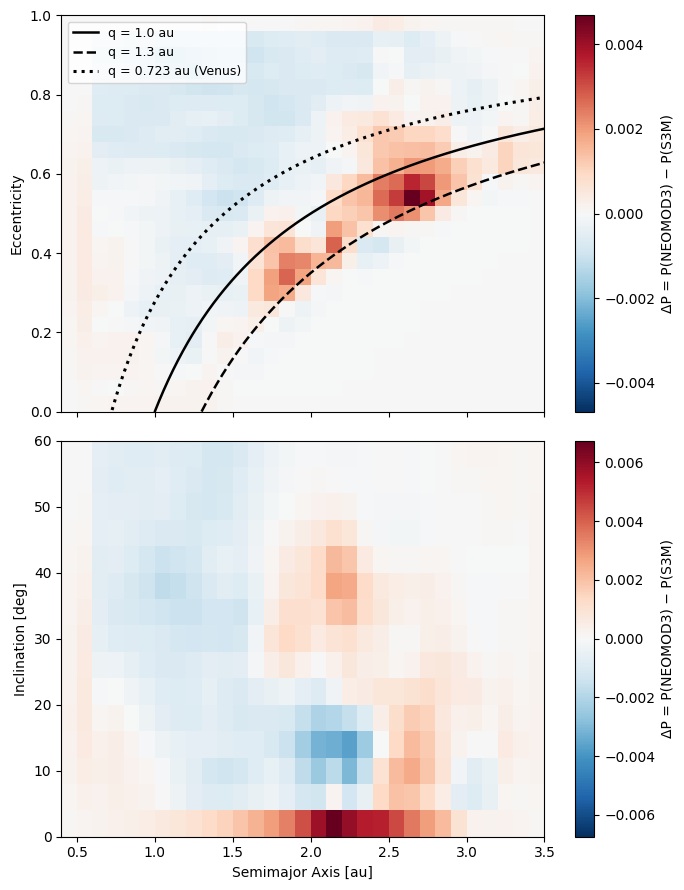

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# fig 1
vmax_ae = np.nanmax(np.abs(d_ae))
vmax_ai = np.nanmax(np.abs(d_ai))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9), sharex=True)

im1 = ax1.pcolormesh(a_edges_nm, e_edges_nm, d_ae.T, shading="auto",
                     cmap="RdBu_r", vmin=-vmax_ae, vmax=vmax_ae)

ax1.set_ylabel("Eccentricity")
ax1.set_ylim(0, 1.0)
fig.colorbar(im1, ax=ax1, label="ΔP = P(NEOMOD3) − P(S3M)")

# Perihelion (q) lines on the a–e panel
# q = a(1 − e)  ->  e = 1 − q/a

a_plot = np.linspace(a_edges_nm[0], a_edges_nm[-1], 800)

def e_of_q(q, a):
    return 1.0 - q / a

q_lines = [
    (1.0,  "-",  1.8, "k", "q = 1.0 au"),
    (1.3,  "--", 1.8, "k", "q = 1.3 au"),
    (0.723, ":", 2.2, "k", "q = 0.723 au (Venus)")
]

for q, ls, lw, col, lab in q_lines:
    e_line = e_of_q(q, a_plot)
    mask = (e_line >= 0.0) & (e_line <= 1.0)
    ax1.plot(a_plot[mask], e_line[mask], linestyle=ls, linewidth=lw, color=col, label=lab)

ax1.legend(loc="upper left", fontsize=9, frameon=True)

# start of fig 2

im2 = ax2.pcolormesh(a_edges_nm, i_edges_nm, d_ai.T, shading="auto",
                     cmap="RdBu_r", vmin=-vmax_ai, vmax=vmax_ai)
ax2.set_xlabel("Semimajor Axis [au]")
ax2.set_ylabel("Inclination [deg]")
ax2.set_ylim(0, 60.0)
fig.colorbar(im2, ax=ax2, label="ΔP = P(NEOMOD3) − P(S3M)")

fig.tight_layout()
plt.show()

